In [338]:
import matplotlib.pyplot as plt
import pandas as pd
import time
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from pmdarima import arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

#### Data Preparation

In [318]:
# Load the datasets
inf = pd.read_excel('Inflation_rates_dataset_2021-2026.xlsx')
macro = pd.read_csv('exogenous_variable_dataset.txt')
sentiment_score = pd.read_csv('finBERT Sentiment-Inflation.csv')

# Turning each month into datetime type
inf['month'] = pd.to_datetime(inf['month']).dt.to_period('M').dt.to_timestamp()
macro['month'] = pd.to_datetime(macro['month']).dt.to_period('M').dt.to_timestamp()
sentiment_score['month'] = pd.to_datetime(sentiment_score['date']).dt.to_period('M').dt.to_timestamp()

# Aligning the sentiment score monthly data format to the first two data

# Inner merge the two data
df = pd.merge(inf, macro, on= 'month', how = 'inner')
# Merging the sentiment
df_final = pd.merge(sentiment_score.drop('inflation', axis =1),df , on = 'month', how = 'left').drop('date', axis = 1)
df_final = df_final[['month', 'inflation', 'usd_php', 'oil_brent', 'sentiment']]
df_final

,month,inflation,usd_php,oil_brent,sentiment
0,2021-01-01,3.7,48.100000,55.000000,-0.096034
1,2021-02-01,4.2,48.318182,56.818182,0.019575
2,2021-03-01,4.1,48.536364,58.636364,-0.041243
3,2021-04-01,4.1,48.754545,60.454545,0.023667
4,2021-05-01,4.1,48.972727,62.272727,-0.017046
...,...,...,...,...,...
60,2026-01-01,2.0,59.160000,64.500000,-0.028967
61,2026-02-01,2.4,58.280000,66.960000,-0.000079
62,2026-03-01,4.1,59.410000,102.860000,0.023276
63,2026-04-01,NaN,NaN,NaN,0.013479


#### Visualizing the relationship of 4 Variables

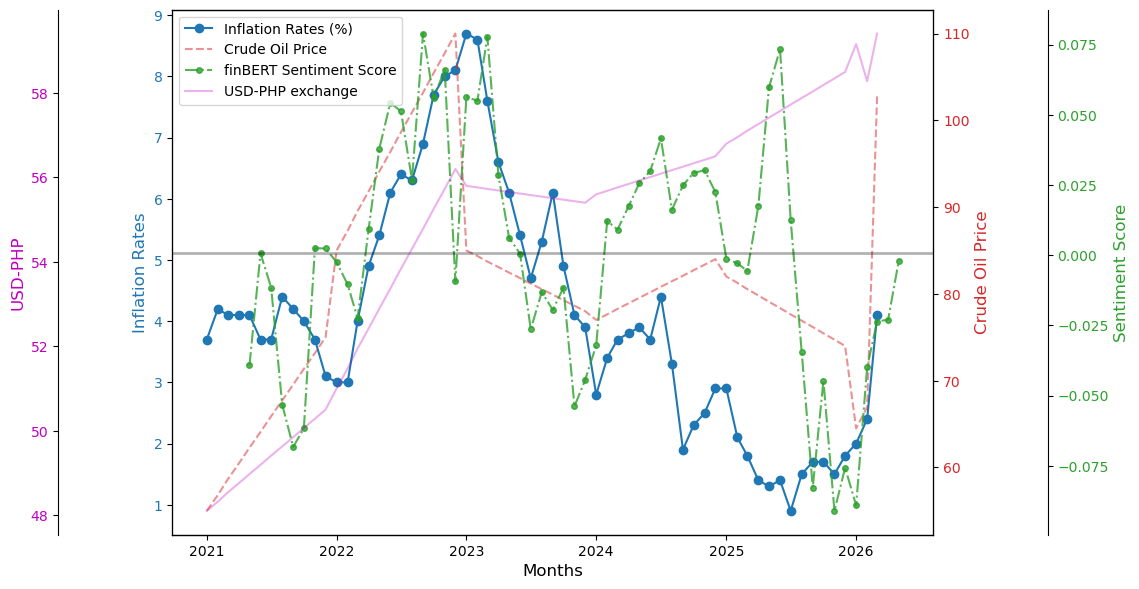

In [319]:
fig, ax1 = plt.subplots(figsize = (12,6))

ax1.plot(df_final['month'], 
         df_final['inflation'], 
         color = 'tab:blue', 
         marker = 'o', 
         label = 'Inflation Rates (%)')
ax1.set_xlabel('Months', 
               fontsize = 12)
ax1.set_ylabel('Inflation Rates', 
               color = 'tab:blue', 
               fontsize =12)
ax1.tick_params('y', 
                labelcolor ='tab:blue')

ax2 = ax1.twinx()

ax2.plot(df_final['month'], 
         df_final['oil_brent'], 
         color = 'tab:red', 
         linestyle = '--',
         alpha = 0.5,
         label = 'Crude Oil Price')
ax2.set_ylabel('Crude Oil Price', color = 'tab:red', fontsize = 12)
ax2.tick_params('y', labelcolor = 'tab:red')

ax3 = ax1.twinx()
# Moving the scale slight to right
ax3.spines['right'].set_position(('axes', 1.15))

ax3.plot(df_final['month'],
         df_final['sentiment'].rolling(window = 3).mean().shift(2), 
         color = 'tab:green', 
         linestyle = '-.',
         alpha = 0.8,
         marker = 'o',
         markersize = 4,
         label = 'finBERT Sentiment Score')
ax3.set_ylabel('Sentiment Score', 
               color = 'tab:green', 
               fontsize = 12)
ax3.tick_params('y', 
                labelcolor = 'tab:green')
ax3.axhline((df_final['sentiment'].rolling(window = 3).mean().shift(2)).mean(), 
             color = 'black', 
             linewidth = 2,
             alpha = 0.3)

ax4 = ax1.twinx()

ax4.yaxis.set_label_position('left')
ax4.yaxis.set_ticks_position('left')
ax4.spines['left'].set_position(('axes', -0.15))
ax4.plot(df_final['month'],
         df_final['usd_php'],
         color = 'm',
         alpha = 0.3,
         label = 'USD-PHP exchange')
ax4.set_ylabel('USD-PHP',
               color = 'm',
               fontsize = 12)
ax4.tick_params('y', labelcolor = 'm')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

ax4.legend(lines+lines2+lines3+lines4,
           labels+labels2+labels3+labels4,
           loc = 'upper left')

fig.tight_layout()
plt.show()

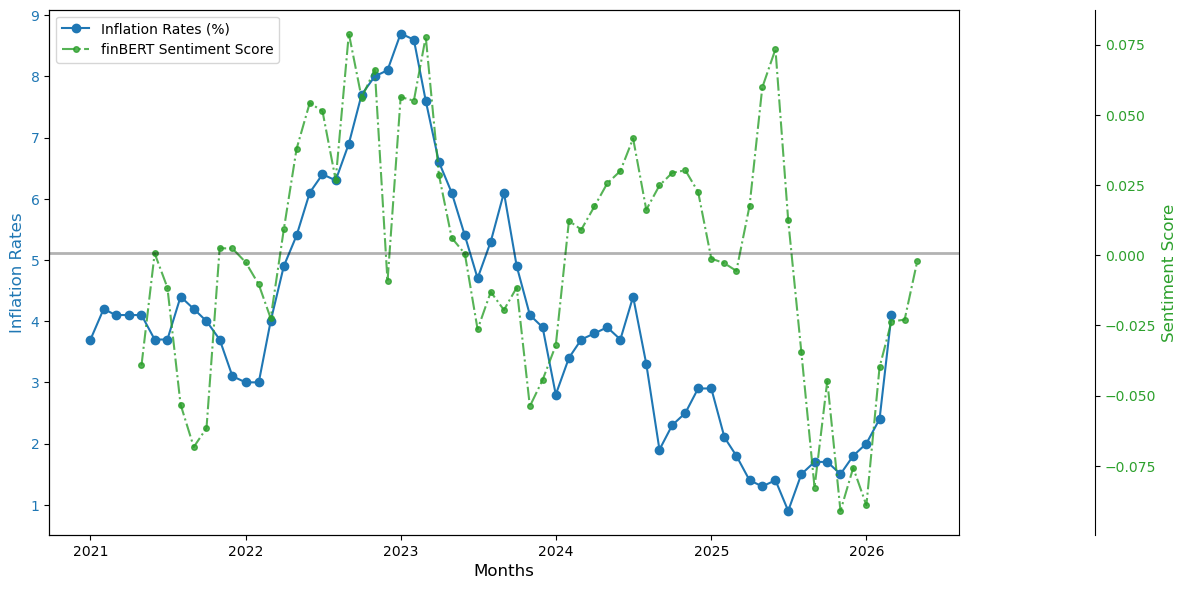

In [320]:
fig, ax1 = plt.subplots(figsize = (12,6))

ax1.plot(df_final['month'], 
         df_final['inflation'], 
         color = 'tab:blue', 
         marker = 'o', 
         label = 'Inflation Rates (%)')
ax1.set_xlabel('Months', 
               fontsize = 12)
ax1.set_ylabel('Inflation Rates', 
               color = 'tab:blue', 
               fontsize =12)
ax1.tick_params('y', 
                labelcolor ='tab:blue')


ax2 = ax1.twinx()
# Moving the scale slight to right
ax2.spines['right'].set_position(('axes', 1.15))

ax2.plot(df_final['month'],
         df_final['sentiment'].rolling(window = 3).mean().shift(2), 
         color = 'tab:green', 
         linestyle = '-.',
         alpha = 0.8,
         marker = 'o',
         markersize = 4,
         label = 'finBERT Sentiment Score')
ax2.set_ylabel('Sentiment Score', 
               color = 'tab:green', 
               fontsize = 12)
ax2.tick_params('y', 
                labelcolor = 'tab:green')
ax2.axhline((df_final['sentiment'].rolling(window = 3).mean().shift(2)).mean(), 
             color = 'black', 
             linewidth = 2,
             alpha = 0.3)


lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()


ax2.legend(lines+lines2,
           labels+labels2,
           loc = 'upper left')

fig.tight_layout()
plt.show()

#### Check correlation of data

In [321]:
inf_sent_corr = df_final['inflation'].corr(df_final['sentiment'].rolling(window = 3).mean().shift(-2))
inf_oil_Corr = df_final['inflation'].corr(df_final['oil_brent'])
inf_USD_Php_Corr = df_final['inflation'].corr(df_final['usd_php'].pct_change())
print(f'Inflation - Sentiment Corr: {inf_sent_corr}')
print(f'Inflatoin - Oil Corr: {inf_oil_Corr}')
print(f'Inflation - USD/PhP Corr: {inf_USD_Php_Corr}')

for lag in [1, 2, 3, 4]:
    lagged_corr = df_final['inflation'].corr(df_final['usd_php'].pct_change().shift(lag))
    print(f"USD/PHP % Change (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

Inflation - Sentiment Corr: 0.34750761144258835
Inflatoin - Oil Corr: 0.4954812059068101
Inflation - USD/PhP Corr: 0.0581293610637927
USD/PHP % Change (Lag 1) vs Inflation Corr: 0.1148
USD/PHP % Change (Lag 2) vs Inflation Corr: 0.3083
USD/PHP % Change (Lag 3) vs Inflation Corr: 0.4272
USD/PHP % Change (Lag 4) vs Inflation Corr: 0.4963


C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_11596\308927822.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inf_USD_Php_Corr = df_final['inflation'].corr(df_final['usd_php'].pct_change())
C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_11596\308927822.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  lagged_corr = df_final['inflation'].corr(df_final['usd_php'].pct_change().shift(lag))


In [322]:
for lag in [1, 2, 3, 4]:
    lagged_corr = df_final['inflation'].corr(df_final['sentiment'].rolling(window = 3).mean().shift(lag))
    print(f"Sentiment (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

Sentiment (Lag 1) vs Inflation Corr: 0.4294
Sentiment (Lag 2) vs Inflation Corr: 0.4417
Sentiment (Lag 3) vs Inflation Corr: 0.4162
Sentiment (Lag 4) vs Inflation Corr: 0.3793


In [323]:
agged_corr = df_final['inflation'].corr(df_final['oil_brent'])
print(agged_corr)
for lag in [1, 2, 3, 4]:
    lagged_corr = df_final['inflation'].corr(df_final['oil_brent'].rolling(window = 3).mean().shift(lag))
    print(f"Oil Brent (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

0.4954812059068101
Oil Brent (Lag 1) vs Inflation Corr: 0.6162
Oil Brent (Lag 2) vs Inflation Corr: 0.6289
Oil Brent (Lag 3) vs Inflation Corr: 0.6164
Oil Brent (Lag 4) vs Inflation Corr: 0.5714


#### Building ARIMA/SARIMA model

In [141]:
# Separating Inflation dataset

# Splitting the data to train-test sets 
train_size = int(len(df_final)*.8)
inf_train = df_final[0:train_size]
inf_test = df_final[train_size:int(len(df_final))]

# Check the data 
print(f'Trainig on: {inf_train.index.min()} to {inf_train.index.max()}')
print(f'Testing on: {inf_test.index.min()} to {inf_test.index.max()}')

Trainig on: 0 to 51
Testing on: 52 to 64


In [142]:
inf_test

,month,inflation,usd_php,oil_brent,sentiment,usd_php_pct_change
52,2025-05-01,1.3,57.418182,79.090909,-0.076016,0.002699
53,2025-06-01,1.4,57.572727,78.363636,-0.048436,0.002692
54,2025-07-01,0.9,57.727273,77.636364,-0.123686,0.002684
55,2025-08-01,1.5,57.881818,76.909091,0.037992,0.002677
56,2025-09-01,1.7,58.036364,76.181818,-0.187360,0.002670
57,2025-10-01,1.7,58.190909,75.454545,-0.077693,0.002663
58,2025-11-01,1.5,58.345455,74.727273,-0.002072,0.002656
59,2025-12-01,1.8,58.500000,74.000000,-0.039782,0.002649
60,2026-01-01,2.0,59.160000,64.500000,-0.028967,0.011282
61,2026-02-01,2.4,58.280000,66.960000,-0.000079,-0.014875


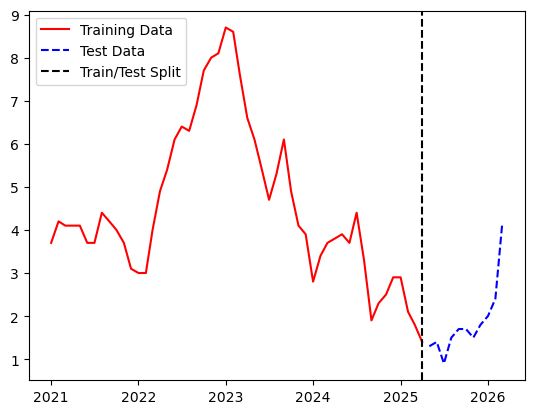

In [143]:
fig = plt.plot(figsize = (30,15))

plt.plot(inf_train['month'], inf_train['inflation'], color  = 'red', label = 'Training Data')
plt.plot(inf_test['month'], inf_test['inflation'], color = 'blue', linestyle = '--', label = 'Test Data')

plt.axvline(inf_train['month'].max(), color = 'black', linestyle = '--', label = 'Train/Test Split')

plt.legend()
plt.show()

### Checking Assumptions for building ARIMA/SARIMA model

##### Stationarity Check

In [144]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)[1]

    if result > 0.05:
        print(f'ADF: {result}, differencing is needed')
    else:
        print(f'ADF: {result}, no differencing needed. Data is stationary')

adf_test(inf_train['inflation'].dropna())

ADF: 0.3546636275136579, differencing is needed


##### Seasonality Check

In [145]:
from pmdarima.arima.utils import nsdiffs

def n_diffs(series):
    result = nsdiffs(series, m = 12, test = 'ocsb')
    print(f'Suggested Seasonal Differencing: {result}')

n_diffs(inf_train['inflation'].dropna())

Suggested Seasonal Differencing: 0


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


##### Seasonal and Trend Decomposition

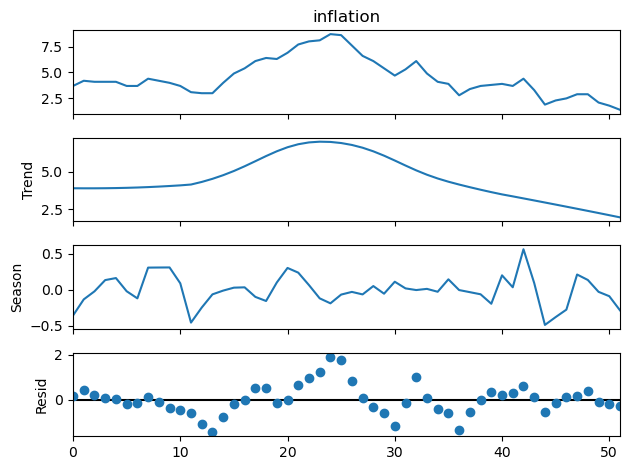

In [146]:
from statsmodels.tsa.seasonal import STL

res = STL(inf_train['inflation'].dropna(), period = 12).fit()
res.plot()
plt.show()

##### ACF/PCF plotting to further check seasonality

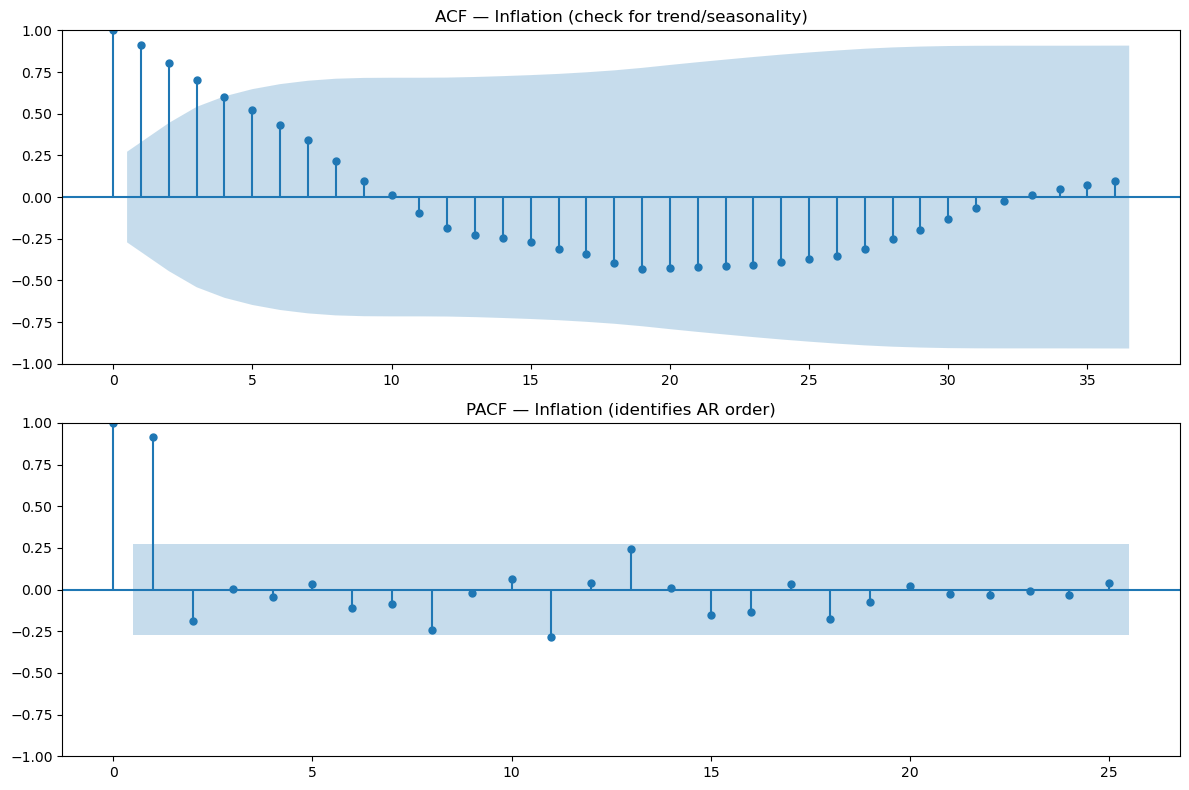

In [147]:
import statsmodels.api as sm

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
sm.graphics.tsa.plot_acf(
    inf_train['inflation'].dropna(),
    lags=36,
    alpha=0.05,
    ax=axes[0],
    title='ACF — Inflation (check for trend/seasonality)'
)

# PACF — run this alongside ACF always
sm.graphics.tsa.plot_pacf(
    inf_train['inflation'].dropna(),
    lags=25,
    alpha=0.05,
    method='ywm',
    ax=axes[1],
    title='PACF — Inflation (identifies AR order)'
)

plt.tight_layout()
plt.show()




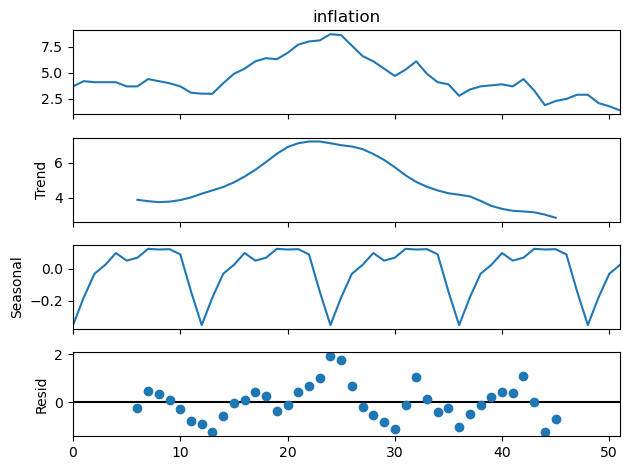

In [148]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(inf_train['inflation'].dropna(),
                            model = 'additive',
                            period = 12)

decomp.plot()
plt.tight_layout()
plt.show()

# This shows that nsdiffs prove that no Seasonal Differencing needed
# While other tests like ACF and PACF and Seasonal Decomposition shows that there is a weak seasonality.
# Auto ARIMA will be used and make sure that Seasonal Differencing is not included

In [149]:
from pmdarima import auto_arima
arima_model = auto_arima(
    inf_train['inflation'].dropna(),
    seasonal=True,
    m=12,
    d=1,          # force differencing since ADF confirmed it
    D=0,          # no seasonal differencing per nsdiffs
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    stepwise=False,   # exhaustive search instead of stepwise
    information_criterion='aic',
    trace=True
)
orders = arima_model.order

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=96.867, Time=0.05 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=81.238, Time=0.09 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.23 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(3,1,1)(0,0,0)[12] intercept   : AIC=88.155, Time=0.06 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(3,1,1)(1,0,0)[12] intercept   : AIC=74.438, Time=0.16 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,2)(0,0,0)[12] intercept   : AIC=89.470, Time=0.19 sec

Best model:  ARIMA(1,1,1)(1,0,0)[12] intercept
Total fit time: 18.259 seconds


In [150]:
train_residuals = arima_model.resid()
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   52
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                 -31.844
Date:                             Wed, 27 May 2026   AIC                             73.688
Time:                                     23:35:33   BIC                             83.347
Sample:                                          0   HQIC                            77.379
                                              - 52                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0642      0.153     -0.421      0.674      -0.363       0.235
ar.L1         -0.4890      0.194     -2.514      0.012      -0.870      -0.108
ma.L1          0.9682      0.124      7.781      0.000       0.724       1.212
ar.S.L12      -0.5216      0.143     -3.659      0.000      -0.801      -0.242
sigma2         0.1810      0.041      4.416      0.000       0.101       0.261
===================================================================================
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):                 0.05
Prob(Q):                              0.74   Prob(JB):                         0.97
Heteroskedasticity (H):               1.20   Skew:                            -0.03
Prob(H) (two-sided):                  0.72   Kurtosis:                         2.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [151]:
inf_train = inf_train.set_index('month')

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   52
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                 -31.844
Date:                             Wed, 27 May 2026   AIC                             73.688
Time:                                     23:35:35   BIC                             83.347
Sample:                                          0   HQIC                            77.379
                                              - 52                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0642      0.153     -0.421      0.674      -0.363       0.235
ar.L1         -0.4890      

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


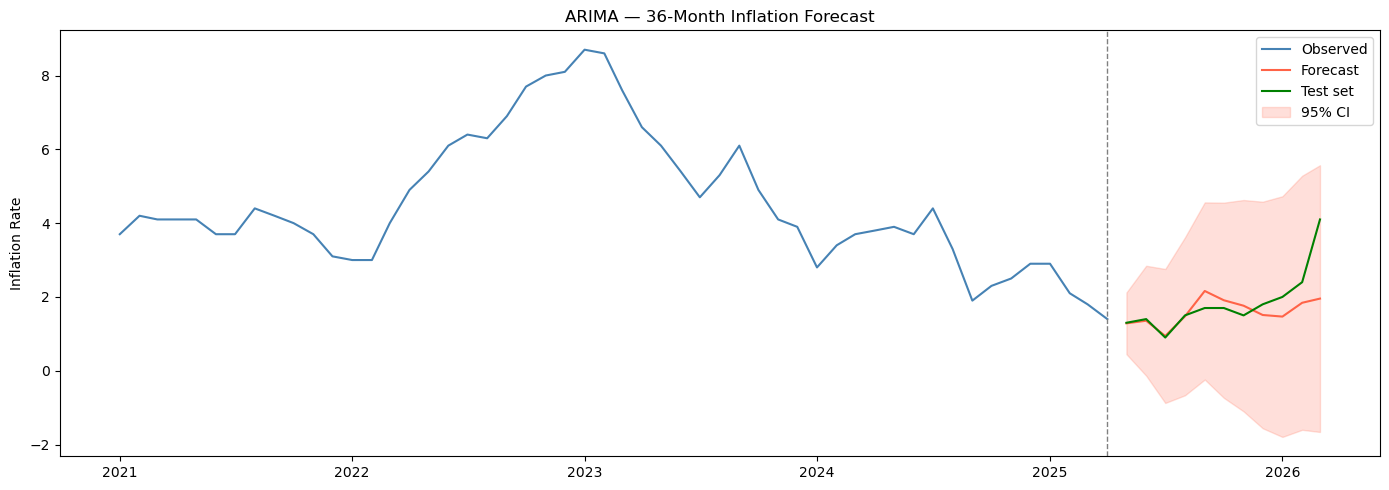

            forecast  lower_ci  upper_ci
2025-05-01  1.284555  0.449224  2.119886
2025-06-01  1.355605 -0.133528  2.844738
2025-07-01  0.942543 -0.872909  2.757995
2025-08-01  1.475526 -0.664714  3.615766
2025-09-01  2.161477 -0.238980  4.561934
2025-10-01  1.910277 -0.734280  4.554834
2025-11-01  1.762556 -1.101118  4.626231
2025-12-01  1.510927 -1.558201  4.580056
2026-01-01  1.467735 -1.793033  4.728503
2026-02-01  1.841915 -1.600255  5.284085
2026-03-01  1.955251 -1.659034  5.569535


In [152]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import pandas as pd


print(arima_model.summary())



# --- Step 2: Forecast 36 months ---
n_forecast = 11
forecast, conf_int = arima_model.predict(n_periods=n_forecast, return_conf_int=True)

last_date = inf_train['inflation'].dropna().index[-1]
forecast_index = pd.date_range(start=last_date, periods=n_forecast + 1, freq='MS')[1:]

forecast_df = pd.DataFrame({
    'forecast':   forecast.values,
    'lower_ci':   conf_int[:, 0],
    'upper_ci':   conf_int[:, 1]
}, index=forecast_index)

# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(inf_train['inflation'], label='Observed', color='steelblue')
ax.plot(forecast_df['forecast'], label='Forecast', color='tomato')
ax.plot(forecast_df.index, inf_test['inflation'].dropna(), label = 'Test set', color = 'green')
ax.fill_between(forecast_df.index,
                forecast_df['lower_ci'],
                forecast_df['upper_ci'],
                alpha=0.2, color='tomato', label='95% CI')

ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1)
ax.set_title('ARIMA — 36-Month Inflation Forecast')
ax.set_ylabel('Inflation Rate')
ax.legend()
plt.tight_layout()
plt.savefig('prelimenary_plot.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print(forecast_df)

In [153]:
len(inf_test['inflation'].dropna())

11

In [263]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

def err_metrics(y_true, y_pred):
    # 1. Mean Squared Error (MSE)
    mse = mean_squared_error(y_true, y_pred)
    
    # 2. Root Mean Squared Error (RMSE)
    # In newer versions of sklearn, you can use squared=False
    rmse = root_mean_squared_error(y_true, y_pred)
    
    # 3. Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")

err_metrics(inf_test['inflation'].dropna(), forecast.values)

MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774


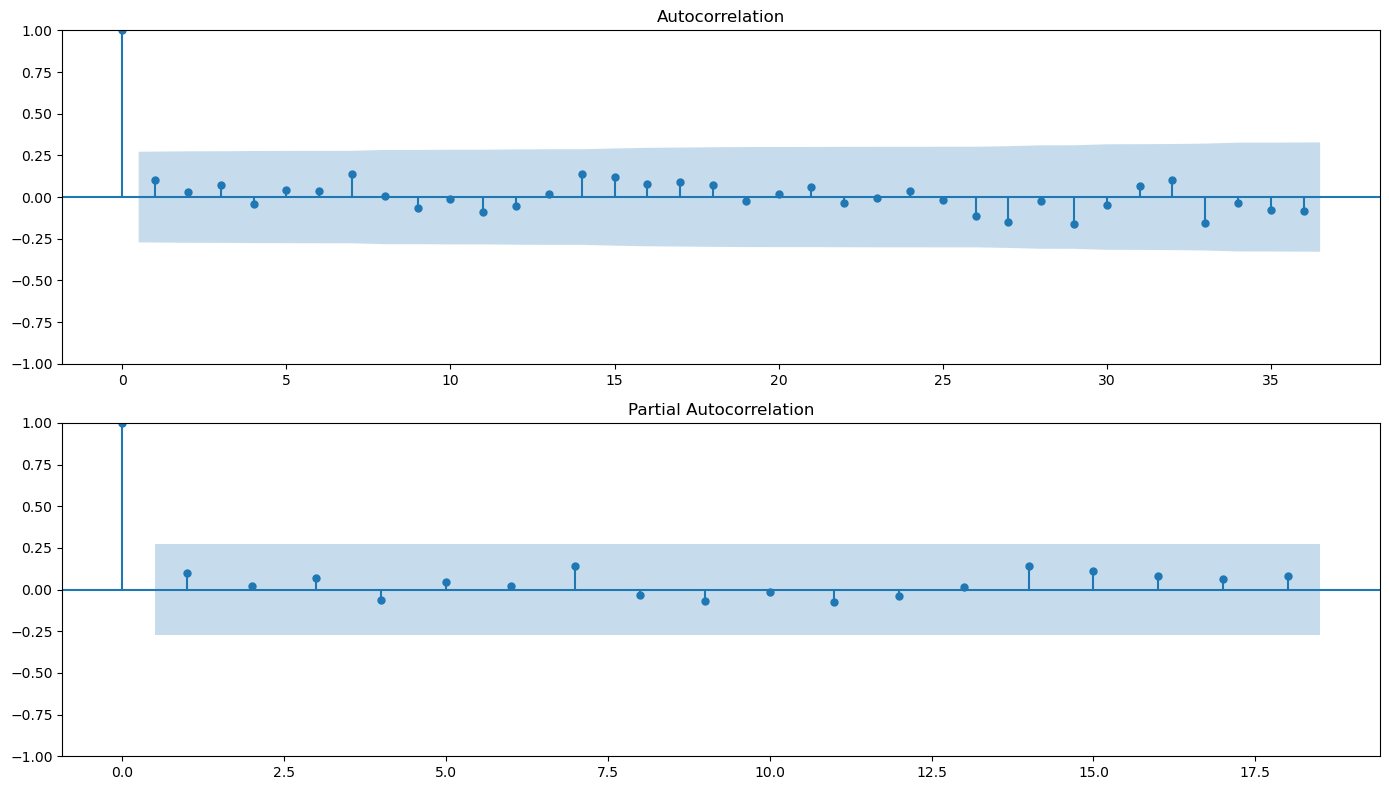

In [155]:
stand_resid = arima_model.resid()

fig, ax = plt.subplots(2,1, figsize = (14,8))

plot_acf(stand_resid, ax = ax[0], lags = 36)
plot_pacf(stand_resid, ax = ax[1], lags = 18)

plt.tight_layout()
plt.show()

In [156]:
sig_lags = [14,15]

In [157]:
train_feature = inf_train.drop(['inflation', 'usd_php_pct_change'], axis = 1).copy()

train_feature

,usd_php,oil_brent,sentiment
month,,,
2021-01-01,48.100000,55.000000,-0.096034
2021-02-01,48.318182,56.818182,0.019575
2021-03-01,48.536364,58.636364,-0.041243
2021-04-01,48.754545,60.454545,0.023667
2021-05-01,48.972727,62.272727,-0.017046
2021-06-01,49.190909,64.090909,-0.166092
2021-07-01,49.409091,65.909091,-0.021759
2021-08-01,49.627273,67.727273,0.003194
2021-09-01,49.845455,69.545455,0.026007


In [158]:
train_feature['usd_php'] = train_feature['usd_php'].pct_change().shift(4)
train_feature['oil_brent'] = train_feature['oil_brent'].rolling(window = 3).mean().shift(2)
train_feature['sentiment'] = train_feature['sentiment'].rolling(window = 3).mean().shift(2)

train_feature = train_feature.dropna()

In [159]:
train_feature

,usd_php,oil_brent,sentiment
month,,,
2021-06-01,0.004536,58.636364,0.000666
2021-07-01,0.004516,60.454545,-0.011541
2021-08-01,0.004495,62.272727,-0.053157
2021-09-01,0.004475,64.090909,-0.068299
2021-10-01,0.004455,65.909091,-0.061552
2021-11-01,0.004435,67.727273,0.002481
2021-12-01,0.004416,69.545455,0.002395
2022-01-01,0.004396,71.363636,-0.002489
2022-02-01,0.004377,73.181818,-0.010425


In [160]:
resid_df = pd.DataFrame(stand_resid, columns = ['target_residuals'])

resid_df = resid_df.iloc[5:].set_index(train_feature.index)

In [161]:
train_feature.loc[:, 'target_residuals'] = resid_df['target_residuals']
train_feature

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_11596\291003642.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_feature.loc[:, 'target_residuals'] = resid_df['target_residuals']


,usd_php,oil_brent,sentiment,target_residuals
month,,,,
2021-06-01,0.004536,58.636364,0.000666,-0.283462
2021-07-01,0.004516,60.454545,-0.011541,0.094319
2021-08-01,0.004495,62.272727,-0.053157,0.656991
2021-09-01,0.004475,64.090909,-0.068299,-0.396841
2021-10-01,0.004455,65.909091,-0.061552,0.088920
2021-11-01,0.004435,67.727273,0.002481,-0.410217
2021-12-01,0.004416,69.545455,0.002395,-0.389586
2022-01-01,0.004396,71.363636,-0.002489,0.116444
2022-02-01,0.004377,73.181818,-0.010425,0.253200


In [162]:
print(train_feature.head())
print(train_feature.shape)
print(train_feature.isnull().sum())

             usd_php  oil_brent  sentiment  target_residuals
month                                                       
2021-06-01  0.004536  58.636364   0.000666         -0.283462
2021-07-01  0.004516  60.454545  -0.011541          0.094319
2021-08-01  0.004495  62.272727  -0.053157          0.656991
2021-09-01  0.004475  64.090909  -0.068299         -0.396841
2021-10-01  0.004455  65.909091  -0.061552          0.088920
(47, 4)
usd_php             0
oil_brent           0
sentiment           0
target_residuals    0
dtype: int64


In [163]:
X = train_feature.drop('target_residuals', axis = 1)
y = train_feature['target_residuals']

In [164]:
rf_model = RandomForestRegressor(
    n_estimators = 500,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X,y)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, n_estimators=500,
                      random_state=42)

In [220]:
test_feature = inf_test.drop(['inflation', 'usd_php_pct_change'], axis = 1).copy()
test_feature['usd_php'] = test_feature['usd_php'].pct_change().shift(4)
test_feature['oil_brent'] = test_feature['oil_brent'].rolling(window = 3).mean().shift(2)
test_feature['sentiment'] = test_feature['sentiment'].rolling(window = 3).mean().shift(2)

test_feature = test_feature.dropna().set_index('month')
test_feature.shape
test_feature

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_11596\1738168176.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  test_feature['usd_php'] = test_feature['usd_php'].pct_change().shift(4)


,usd_php,oil_brent,sentiment
month,,,
2025-10-01,0.002692,77.636364,-0.044710
2025-11-01,0.002684,76.909091,-0.091018
2025-12-01,0.002677,76.181818,-0.075687
2026-01-01,0.002670,75.454545,-0.089042
2026-02-01,0.002663,74.727273,-0.039849
2026-03-01,0.002656,71.075758,-0.023607
2026-04-01,0.002649,68.486667,-0.022942
2026-05-01,0.011282,78.106667,-0.001923


In [256]:
boundary_df = pd.concat([inf_train.tail(4).drop(['inflation', 'usd_php_pct_change'],axis = 1), inf_test.drop(['inflation', 'usd_php_pct_change'],axis = 1)])

boundary_df['usd_php'] = boundary_df['usd_php'].pct_change().shift(4)
boundary_df['oil_brent'] = boundary_df['oil_brent'].rolling(window = 3).mean().shift(2)
boundary_df['sentiment'] = boundary_df['sentiment'].rolling(window = 3).mean().shift(2)

test_feature = boundary_df.iloc[6:].set_index('month')

print(f'Train length: {len(train_feature)}')
test_feature

Train length: 11


C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_11596\597943373.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  boundary_df['usd_php'] = boundary_df['usd_php'].pct_change().shift(4)


,usd_php,oil_brent,sentiment
month,,,
2025-07-01,0.002713,79.818182,0.012431
2025-08-01,0.002706,79.090909,-0.034575
2025-09-01,0.002699,78.363636,-0.082713
2025-10-01,0.002692,77.636364,-0.044710
2025-11-01,0.002684,76.909091,-0.091018
2025-12-01,0.002677,76.181818,-0.075687
2026-01-01,0.002670,75.454545,-0.089042
2026-02-01,0.002663,74.727273,-0.039849
2026-03-01,0.002656,71.075758,-0.023607


In [257]:
rf_residual_pred = rf_model.predict(test_feature)

In [258]:
corrected_rf_forecast = forecast.values[:len(rf_residual_pred)]+rf_residual_pred
corrected_rf_forecast

array([0.99935754, 1.33030908, 0.96774375, 1.5158656 , 2.15644497,
       1.90524503, 1.75601401, 1.53837382, 1.73942328, 2.11765451,
       2.14127907])

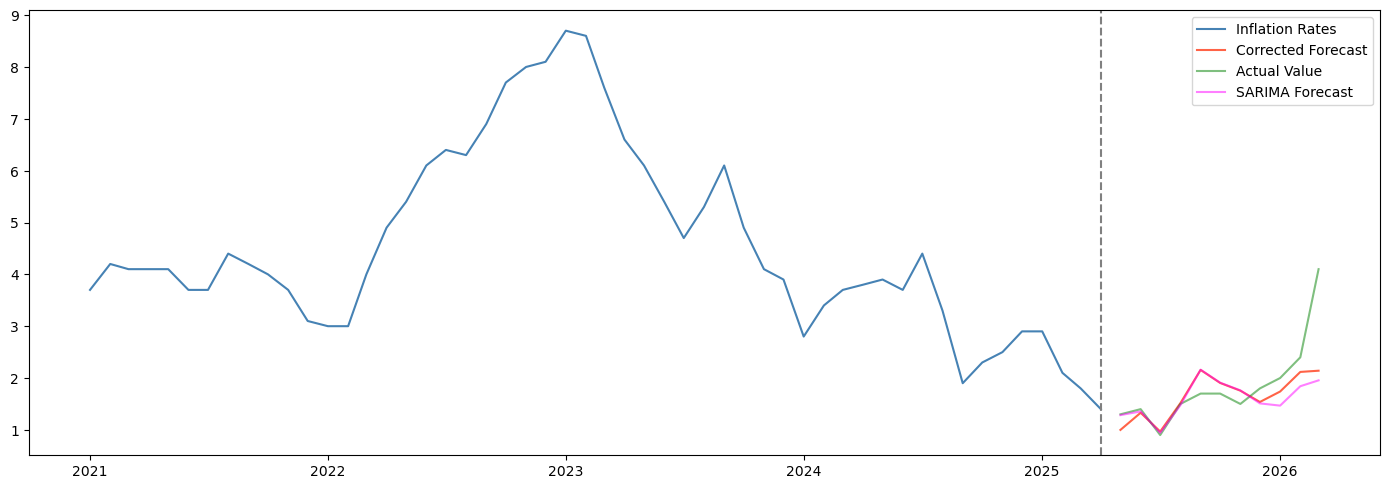

In [399]:
last_date = inf_train.index[-1]
index_range = pd.date_range(start = last_date, periods = len(corrected_rf_forecast)+1, freq='MS')[1:]

fig, ax = plt.subplots(figsize = (14,5))

ax.plot(inf_train.index, inf_train['inflation'], color = 'steelblue', label = 'Inflation Rates')
ax.plot(index_range, corrected_rf_forecast, color = 'tomato', label = 'Corrected Forecast')
ax.plot(index_range, inf_test['inflation'][0:11], color = 'green',alpha = 0.5, label = 'Actual Value')
ax.plot(index_range, forecast[0:11], color = 'magenta', alpha = 0.5, label = 'SARIMA Forecast')

ax.axvline(x = last_date, color = 'gray', linestyle = '--')
plt.legend()
plt.tight_layout()
plt.show()

In [400]:
inf_test['inflation'].dropna().shape

(11,)

In [401]:
print(f'ARIMA Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), forecast.values[:11])
print('')
print(f'Corrected RF Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_rf_forecast)

ARIMA Forecast Error Matrix:
MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774

Corrected RF Forecast Error Matrix:
MSE: 0.4062499535173513
RMSE: 0.6373774027351075
MAE: 0.37590146111045636


In [402]:
xgb_model = XGBRegressor(
    n_estimators = 500,
    max_depth = 3,
    learning_rate = 0.05,
    random_state = 42
)

xgb_model.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [403]:
xgb_forecast = xgb_model.predict(test_feature)

corrected_xgb_forecast = forecast.values[:len(rf_residual_pred)]+xgb_forecast
corrected_xgb_forecast

array([0.98237632, 1.63565366, 0.61537106, 1.79355504, 1.89131515,
       1.64011522, 1.49239449, 1.68210923, 1.63085521, 2.00503528,
       2.08340756])

In [404]:
print(f'ARIMA Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), forecast.values[:11])
print('')
print(f'Corrected RF Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_rf_forecast)
print('')
print(f'Corrected XGBoost Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_xgb_forecast)

ARIMA Forecast Error Matrix:
MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774

Corrected RF Forecast Error Matrix:
MSE: 0.4062499535173513
RMSE: 0.6373774027351075
MAE: 0.37590146111045636

Corrected XGBoost Forecast Error Matrix:
MSE: 0.4306054072858634
RMSE: 0.6562053087912832
MAE: 0.3898963176104862


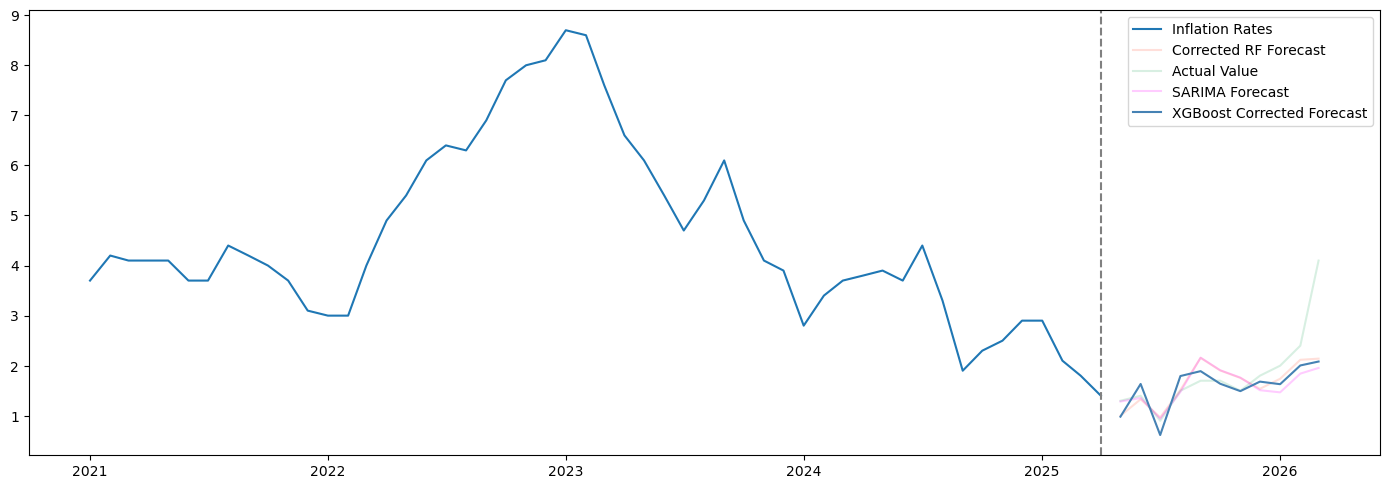

In [405]:
fig, ax = plt.subplots(figsize = (14,5))

ax.plot(inf_train.index, inf_train['inflation'], label = 'Inflation Rates')
ax.plot(index_range, corrected_rf_forecast, color = 'tomato', label = 'Corrected RF Forecast', alpha = 0.2)
ax.plot(index_range, inf_test['inflation'][0:11], color = 'mediumseagreen',alpha = 0.2, label = 'Actual Value')
ax.plot(index_range, forecast[0:11], color = 'magenta', label = 'SARIMA Forecast', alpha = 0.2)
ax.plot(index_range, corrected_xgb_forecast, color = 'steelblue', label = 'XGBoost Corrected Forecast')

ax.axvline(x = last_date, color = 'gray', linestyle = '--')
plt.legend()
plt.tight_layout()
plt.show()

In [406]:
ensembled_model = (corrected_rf_forecast + corrected_xgb_forecast)/2

print(f'ARIMA Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), forecast.values[:11])
print('')
print(f'Corrected RF Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_rf_forecast)
print('')
print(f'Corrected XGBoost Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_xgb_forecast)
print('')
print(f'Corrected Ensemble Model Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), ensembled_model)

ARIMA Forecast Error Matrix:
MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774

Corrected RF Forecast Error Matrix:
MSE: 0.4062499535173513
RMSE: 0.6373774027351075
MAE: 0.37590146111045636

Corrected XGBoost Forecast Error Matrix:
MSE: 0.4306054072858634
RMSE: 0.6562053087912832
MAE: 0.3898963176104862

Corrected Ensemble Model Forecast Error Matrix:
MSE: 0.40585123489070385
RMSE: 0.6370645453097384
MAE: 0.36426934708128905


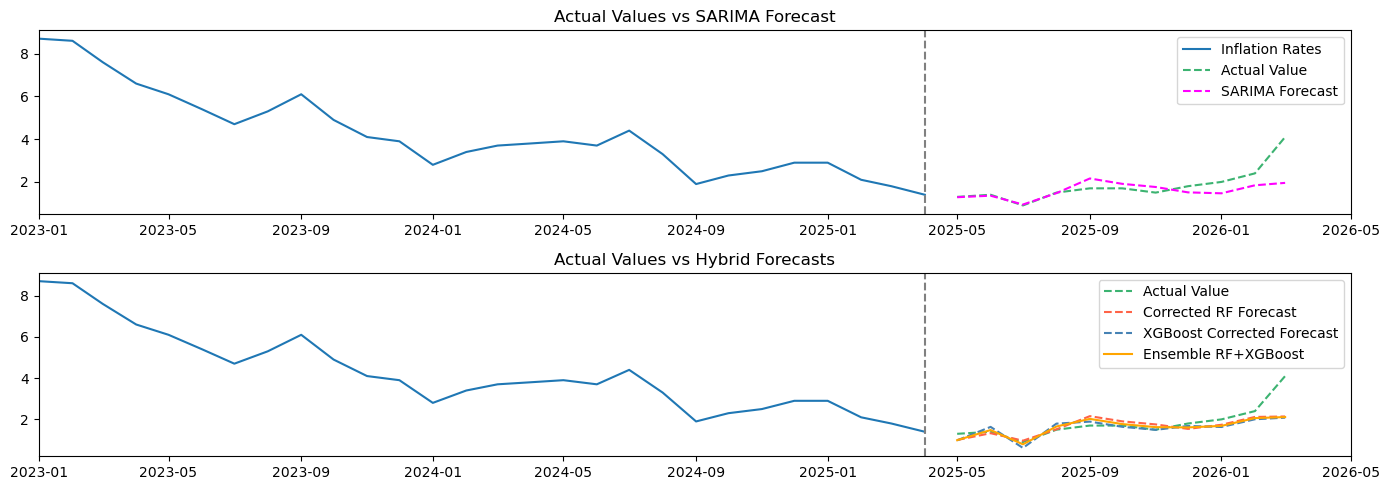

In [407]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (14,5))

ax1.plot(inf_train.index, inf_train['inflation'], label = 'Inflation Rates')
ax1.plot(index_range, inf_test['inflation'][0:11], color = 'mediumseagreen',linestyle = '--', label = 'Actual Value')
ax1.plot(index_range, forecast[0:11], color = 'magenta', label = 'SARIMA Forecast', linestyle = '--')
ax1.set_title('Actual Values vs SARIMA Forecast')
ax1.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2026-05-01'))
ax1.legend()

ax2.plot(inf_train.index, inf_train['inflation'])
ax2.plot(index_range, inf_test['inflation'][0:11], color = 'mediumseagreen',linestyle = '--', label = 'Actual Value')
ax2.plot(index_range, corrected_rf_forecast, color = 'tomato', label = 'Corrected RF Forecast', linestyle = '--')
ax2.plot(index_range, corrected_xgb_forecast, color = 'steelblue', label = 'XGBoost Corrected Forecast',linestyle = '--')
ax2.plot(index_range, ensembled_model, color = 'orange', label = 'Ensemble RF+XGBoost')
ax2.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2026-05-01'))
ax2.set_title('Actual Values vs Hybrid Forecasts')
ax2.legend()

ax1.axvline(x = last_date, color = 'gray', linestyle = '--')
ax2.axvline(x = last_date, color = 'gray', linestyle = '--')



plt.tight_layout()
plt.savefig('Model_evaluation_plot.png', dpi = 150, bbox_inches = 'tight')
plt.show()

#### Feature Engineering for Full Dataset

In [333]:
df_feature_engineered = df_final.copy()
df_feature_engineered['usd_php'] = df_feature_engineered['usd_php'].pct_change().shift(4)
df_feature_engineered['oil_brent'] = df_feature_engineered['oil_brent'].rolling(window = 3).mean().shift(2)
df_feature_engineered['sentiment'] = df_feature_engineered['sentiment'].rolling(window = 3).mean().shift(2)

df_feature_engineered = df_feature_engineered.dropna().set_index('month')

print(f'Original df shape: {df_final.shape}')
print(f'Engineered shape: {df_feature_engineered.shape}')
print(f'Row dropped: {len(df_final) - len(df_feature_engineered)}')
df_feature_engineered.tail()

Original df shape: (65, 5)
Engineered shape: (58, 4)
Row dropped: 7


C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_11596\972258728.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_feature_engineered['usd_php'] = df_feature_engineered['usd_php'].pct_change().shift(4)


,inflation,usd_php,oil_brent,sentiment
month,,,,
2025-11-01,1.5,0.002684,76.909091,-0.091018
2025-12-01,1.8,0.002677,76.181818,-0.075687
2026-01-01,2.0,0.002670,75.454545,-0.089042
2026-02-01,2.4,0.002663,74.727273,-0.039849
2026-03-01,4.1,0.002656,71.075758,-0.023607


#### Refitting Full Dataset to SARIMA model

In [353]:
final_arima_model = SARIMAX(
    df_feature_engineered['inflation'],
    order = orders,
    seasonal_order= arima_model.seasonal_order,
    freq='MS'
)

final_arima_fit = final_arima_model.fit(disp = False)

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Prediction

In [395]:
forecast_length = 36
final_arima_forecast = final_arima_fit.get_forecast(steps = forecast_length)

forecast_values = final_arima_forecast.predicted_mean
forecast_ci = final_arima_forecast.conf_int()

forecast_values
forecast_ci

,lower inflation,upper inflation
2026-04-01,3.569736,5.358398
2026-05-01,2.912784,5.934540
2026-06-01,2.606980,6.249927
2026-07-01,2.509058,6.808312
2026-08-01,1.962737,6.760341
2026-09-01,1.597124,6.885382
2026-10-01,1.392588,7.107033
2026-11-01,1.288957,7.413012
2026-12-01,0.944410,7.444701
2027-01-01,0.655845,7.516239


#### Plotting 36-month horizon forecast

In [380]:
last_date = df_feature_engineered.index[-1]

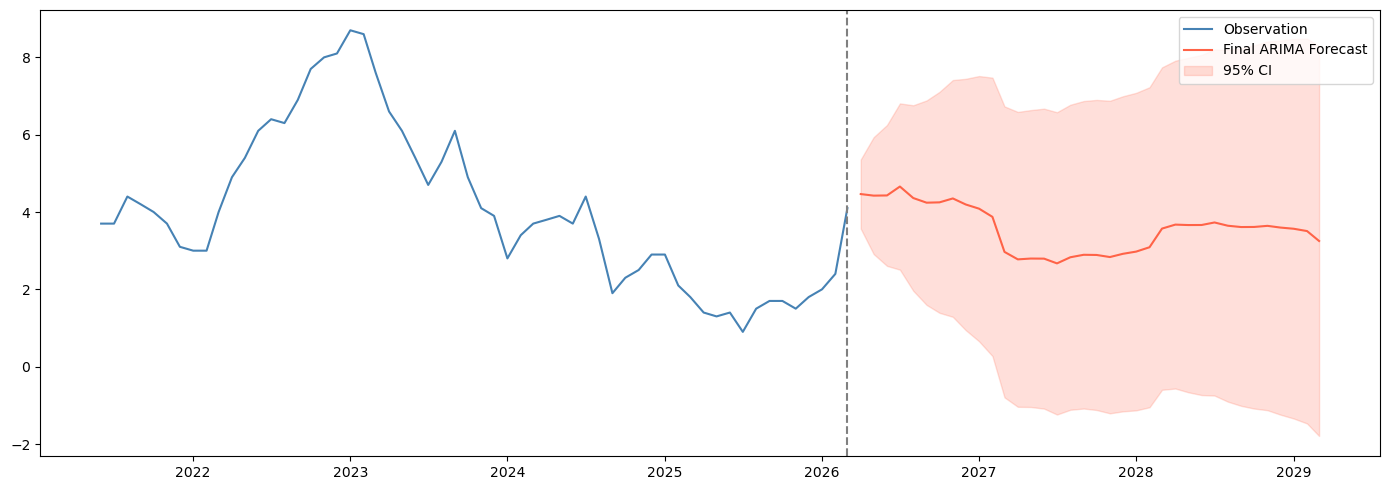

In [396]:
fig, ax = plt.subplots(figsize = (14,5))

ax.plot(df_feature_engineered['inflation'], color = 'steelblue', label  = 'Observation')
ax.plot(forecast_values.index, forecast_values.values, color = 'tomato', label = 'Final ARIMA Forecast')
ax.fill_between(
    forecast_values.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha = 0.2, color = 'tomato', label = '95% CI')

ax.axvline(last_date, linestyle = '--', color = 'grey')
plt.legend()
plt.tight_layout()
plt.show()